# 228 — Putative MHC-related genes in *Botryllus schlosseri*, predicted from what zebrafish and fly show

**Question:** the midi-plus run searched the human MHC queries against *Botryllus
schlosseri*, a colonial tunicate at the same 550 Mya node as ciona, but could not score the
hits because Botryllus has no Pfam annotation in the run. What do the hits look like, and which
Botryllus proteins can be called MHC-related on the strength of them?

**The prediction, before looking.** Notebooks [221](./221_mhc_cross_species_detection_depth.ipynb)
and [224](./224_detect_vs_boundary_match_and_the_annotation_floor.ipynb) established the pattern in the
scored species. In zebrafish (430 Mya, a jawed vertebrate with a real MHC) the human class I
and class II queries hit targets on both halves of the molecule, the peptide-binding platform
and the Ig C1-set. In fly (600 Mya) only the Ig half finds a partner, one C1-set protein, and
the platform finds nothing. In ciona (550 Mya, a tunicate) the Pfam map holds no platform and no
C1-set at all. Botryllus is ciona's relative, so the prediction is the fly pattern or less:
hits from the Ig C1-set half of the MHC molecules onto immunoglobulin-superfamily proteins,
hits from the TAP transporters onto ABC transporters, and no hit from the platform. A
Botryllus protein hit on the platform half by more than one tool would be the interesting
exception. The Botryllus histocompatibility factor BHF (`FUN008084_FUN008084`), which this
project treats as a case of a non-MHC histocompatibility system, is checked by name.

**Tools.** Six sequence tools searched Botryllus: phmmer, jackhmmer, MMseqs2, MMseqs2
iterative, HHblits and ProstT5 (3Di predicted from sequence). No structure tool did, because
Botryllus has no AlphaFold models. kmerseek searched Botryllus only inside the all-QfO run that
shares the results directory, so only that run's arms exist: protein20 k=10, hsdm17 k=10,
uniprot18 k=10, wass14 k=12 and mmseqs12 k=6, all without the low-complexity mask, and none of
the HP alphabets. The command that would add the HP arms is at the end. Every figure names its
tools; *arm* means one tool at one setting.

**Queries.** The 25 curated MHC genes (24 on chr6 plus B2M), the six class I-like CD1A-E and
MR1, and the 27 KIR/LILR receptors, 58 proteins in all, with each hit assigned to the human
domain it covers: peptide-binding platform, Ig C1-set, class I tail, ABC transporter (TAP),
CD1 platform, or receptor Ig.

In [1]:
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

import mhc_region_utils as mu

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

SPECIES = ["zebrafish", "fly", "ciona", "botryllus"]
SEQ_TOOLS = ["hmmer3_phmmer", "hmmer3_jackhmmer", "mmseqs2_seqseq", "mmseqs2_iterative", "hhblits", "prostt5"]
EVALUE = 1e-3  # one cut for every tool, so counts are comparable across tools
BHF = "FUN008084_FUN008084"

gene_map = mu.load_query_gene_map()
truth = pl.concat([mu.core_truth(), mu.extras_truth()], how="diagonal_relaxed")
# One label per query: MHC class for the curated genes, the added group otherwise.
QUERY = (
    gene_map.filter(pl.col("mhc_class_ext").is_not_null())
    .select(query_acc="accession", hgnc_symbol="hgnc_symbol", group="mhc_class_ext", query_set="query_set")
)
QACC = QUERY["query_acc"].to_list()
DOMS = truth.select("query_acc", "pfam_id", "role", "domain_start", "domain_end").filter(pl.col("role").is_not_null())
ROLE_ORDER = ["peptide-binding platform", "CD1 platform", "Ig C1-set", "class I tail", "Ig (receptor)", "ABC transporter"]

print(mu.RUN_SUMMARY)
print(f"\nqueries: {QUERY.height} ({QUERY.filter(pl.col('query_set') == 'chr6').height} curated chr6 + "
      f"{QUERY.filter(pl.col('query_set') != 'chr6').height} added off chr6)")
print(QUERY.group_by("group").len().sort("len", descending=True))
print(f"scored domains on them: {DOMS.height}")
print(DOMS.group_by("role").len().sort("len", descending=True))


def _ov(a0, a1, b0, b1):
    return (pl.min_horizontal(a1, b1) - pl.max_horizontal(a0, b0)).clip(lower_bound=0)


def label_hits(hits: pl.DataFrame, qs="qstart", qe="qend", by="domain") -> pl.DataFrame:
    """Attach the human domain each hit lands on, keeping the best-covered one.

    by="domain": the hit covers at least half of the domain (an alignment). by="hit": at
    least half of the hit lies inside the domain, which is the right test for a kmerseek
    matched window, whose length is k and can never cover half of an 80-residue domain.
    """
    j = (
        hits.join(DOMS, on="query_acc", how="inner")
        .with_columns(ov=_ov(qs, qe, "domain_start", "domain_end"),
                      dlen=pl.col("domain_end") - pl.col("domain_start") + 1,
                      hlen=pl.col(qe) - pl.col(qs) + 1)
        .with_columns(frac=pl.col("ov") / (pl.col("dlen") if by == "domain" else pl.col("hlen")))
        .filter(pl.col("frac") >= 0.5)
        .sort("frac", descending=True)
    )
    keys = [c for c in hits.columns]
    return j.group_by(keys, maintain_order=True).agg(pl.all().first())


base = (
    pl.scan_parquet(mu.BASELINE_REGIONS)
    .filter(pl.col("species").is_in(SPECIES) & pl.col("query_acc").is_in(QACC) & pl.col("tool").is_in(SEQ_TOOLS))
    .select("species", "tool", "query_acc", "target_acc", "qstart", "qend", "tstart", "tend", "score", "evalue")
    .collect()
)
print(f"\nsequence-tool hits on the {len(QACC)} queries, four species: {base.height:_}")
base = base.filter(pl.col("evalue") <= EVALUE)
print(f"after e-value <= {EVALUE:g}: {base.height:_}")
HITS = label_hits(base).join(QUERY, on="query_acc")
print(f"hits that cover >= half of a scored human domain: {HITS.height:_}")
with pl.Config(tbl_rows=30, tbl_width_chars=160):
    print(HITS.group_by("species", "tool").agg(n_hits=pl.len(), n_targets=pl.col("target_acc").n_unique(),
                                               n_queries=pl.col("query_acc").n_unique()).sort("species", "tool"))

Run: QfO Pfam-region benchmark, midi-plus (2026-09-01 to 09-02, 4,723 tasks). 998 human queries: 964 chromosome 6 proteins plus B2M, CD1A-E, MR1 and 27 KIR/LILR receptors. Targets: mouse, chicken, zebrafish, ciona, fly, worm, yeast, Arabidopsis and E. coli, all scored against Pfam; Botryllus schlosseri searched but unscored.

queries: 58 (24 curated chr6 + 34 added off chr6)
shape: (9, 2)
┌─────────────────────┬─────┐
│ group               ┆ len │
│ ---                 ┆ --- │
│ str                 ┆ u32 │
╞═════════════════════╪═════╡
│ receptor (KIR/LILR) ┆ 27  │
│ II beta             ┆ 7   │
│ II alpha            ┆ 6   │
│ I-like (CD1/MR1)    ┆ 6   │
│ processing (ctrl)   ┆ 3   │
│ I non-classical     ┆ 3   │
│ I classical         ┆ 3   │
│ I related (MIC)     ┆ 2   │
│ light chain         ┆ 1   │
└─────────────────────┴─────┘
scored domains on them: 129
shape: (6, 2)
┌──────────────────────────┬─────┐
│ role                     ┆ len │
│ ---                      ┆ --- │
│ str      

## 1. The reference pattern: which half of the MHC molecule finds a partner, by species

For each species and tool, how many of the 25 curated MHC genes have at least one hit (e-value
≤ 1e-3) whose human interval covers at least half of a platform domain, of an Ig C1-set domain,
or of a TAP ABC-transporter domain. Zebrafish should light up on all three, fly on the Ig half
and TAP only, ciona on TAP only. Botryllus is the column the prediction is about.

One tool needs a warning before the figure. ProstT5 is Foldseek run on 3Di predicted from
sequence, and its e-values come from Foldseek's structural scoring, not from a sequence null.
At e-value ≤ 1e-3 it reports platform partners for most class I and class II genes in every
species, ciona included, where the Pfam map has no platform at all. Its e-values are therefore
not on the same scale as the other five, and nothing below counts a ProstT5 hit unless another
tool agrees.

curated MHC genes with a hit covering >= half the domain, by role (denominator = genes carrying that role):
{'peptide-binding platform': 21, 'Ig C1-set': 23, 'ABC transporter': 2}
shape: (24, 5)
┌───────────┬───────────────────┬──────────────────────────┬───────────┬─────────────────┐
│ species   ┆ tool              ┆ peptide-binding platform ┆ Ig C1-set ┆ ABC transporter │
│ ---       ┆ ---               ┆ ---                      ┆ ---       ┆ ---             │
│ str       ┆ str               ┆ u32                      ┆ u32       ┆ u32             │
╞═══════════╪═══════════════════╪══════════════════════════╪═══════════╪═════════════════╡
│ botryllus ┆ hhblits           ┆ 0                        ┆ 0         ┆ 2               │
│ botryllus ┆ hmmer3_jackhmmer  ┆ 0                        ┆ 1         ┆ 2               │
│ botryllus ┆ hmmer3_phmmer     ┆ 0                        ┆ 0         ┆ 2               │
│ botryllus ┆ mmseqs2_iterative ┆ 1                        ┆ 2         ┆ 2   

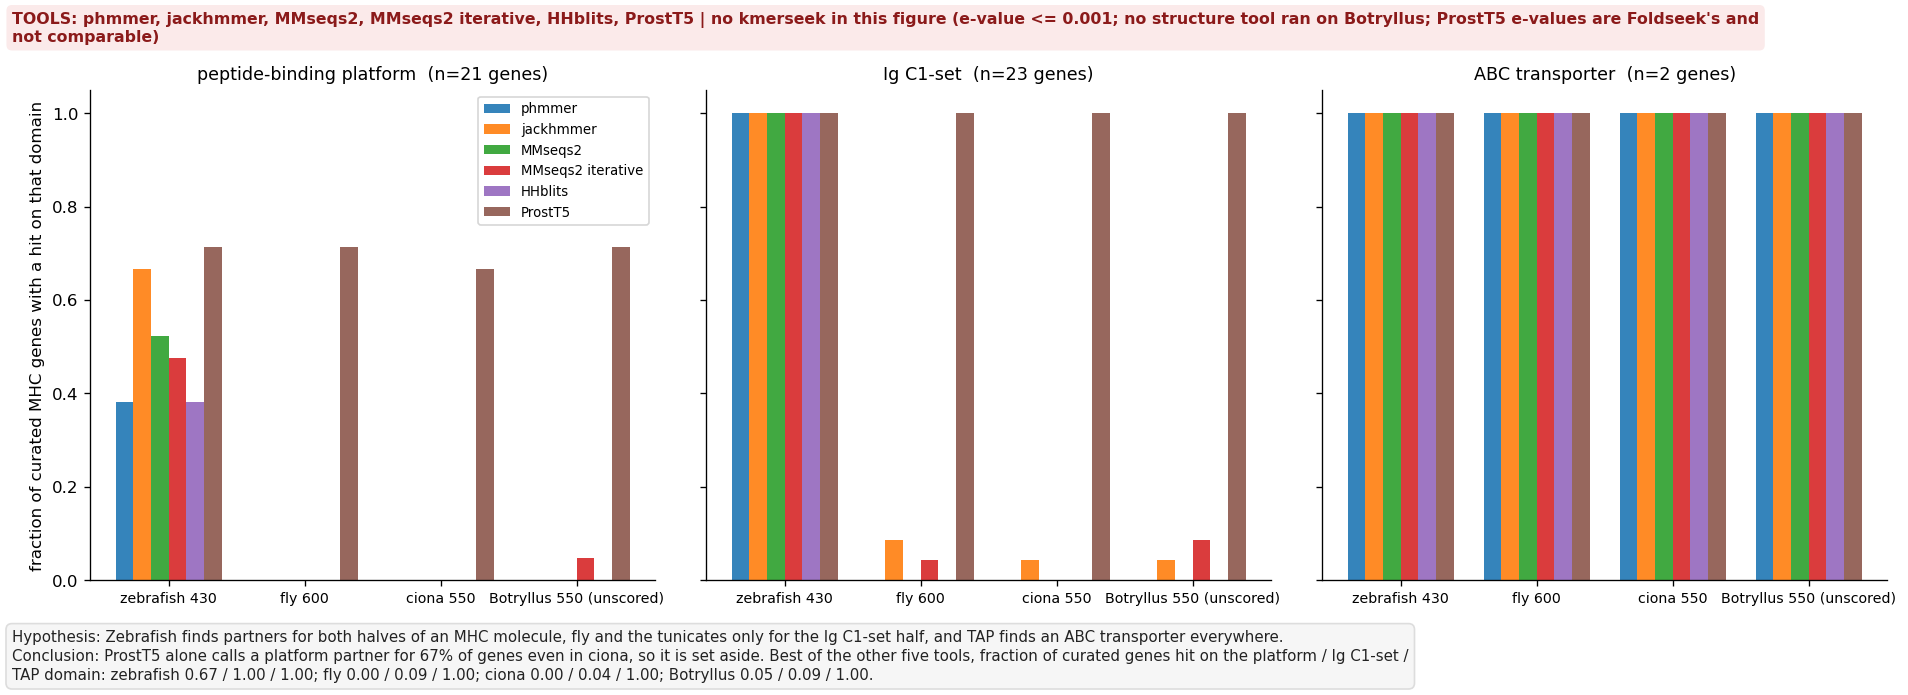

In [2]:
CORE_ACC = QUERY.filter(pl.col("query_set") == "chr6")["query_acc"].to_list() + QUERY.filter(pl.col("query_set") == "b2m")["query_acc"].to_list()
ROLE3 = ["peptide-binding platform", "Ig C1-set", "ABC transporter"]
n_role = {r: DOMS.filter(pl.col("query_acc").is_in(CORE_ACC) & (pl.col("role") == r))["query_acc"].n_unique() for r in ROLE3}

cnt = (
    HITS.filter(pl.col("query_acc").is_in(CORE_ACC) & pl.col("role").is_in(ROLE3))
    .group_by("species", "tool", "role")
    .agg(n_genes=pl.col("query_acc").n_unique(), n_targets=pl.col("target_acc").n_unique())
)
grid = (
    pl.DataFrame({"species": SPECIES}).join(pl.DataFrame({"tool": SEQ_TOOLS}), how="cross")
    .join(pl.DataFrame({"role": ROLE3}), how="cross")
    .join(cnt, on=["species", "tool", "role"], how="left")
    .with_columns(pl.col("n_genes").fill_null(0), pl.col("n_targets").fill_null(0))
    .with_columns(frac=pl.col("n_genes") / pl.col("role").replace_strict(n_role))
)
print("curated MHC genes with a hit covering >= half the domain, by role (denominator = genes carrying that role):")
print(n_role)
with pl.Config(tbl_rows=80, tbl_width_chars=160):
    print(grid.pivot(on="role", index=["species", "tool"], values="n_genes").sort("species", "tool"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
x = np.arange(len(SPECIES)); w = 0.13
for ax, role in zip(axes, ROLE3):
    for k, tool in enumerate(SEQ_TOOLS):
        v = [grid.filter((pl.col("species") == s) & (pl.col("tool") == tool) & (pl.col("role") == role))["frac"][0] for s in SPECIES]
        ax.bar(x + (k - 2.5) * w, v, w, label=mu.TOOL_LABELS[tool], color=plt.get_cmap("tab10")(k), alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([mu.SPECIES_LABELS[s].replace("\n", " ") for s in SPECIES], fontsize=8.5)
    ax.set_title(f"{role}  (n={n_role[role]} genes)", fontsize=10.5)
    ax.set_ylim(0, 1.05)
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
axes[0].set_ylabel("fraction of curated MHC genes with a hit on that domain")
axes[0].legend(fontsize=8, loc="upper right")
def _f(sp, role):
    return grid.filter((pl.col("species") == sp) & (pl.col("role") == role) & (pl.col("tool") != "prostt5"))["frac"].max()
def _p(sp, role):
    return grid.filter((pl.col("species") == sp) & (pl.col("role") == role) & (pl.col("tool") == "prostt5"))["frac"].max()
mu.finish_figure(
    fig,
    FIG_DIR / "228_reference_pattern.png",
    tools=mu.tools_text(SEQ_TOOLS, note=f"e-value <= {EVALUE:g}; no structure tool ran on Botryllus; ProstT5 e-values are Foldseek's and not comparable"),
    hypothesis="Zebrafish finds partners for both halves of an MHC molecule, fly and the tunicates only for the Ig C1-set half, and TAP finds an ABC transporter everywhere.",
    conclusion=(
        f"ProstT5 alone calls a platform partner for {_p('ciona', ROLE3[0]):.0%} of genes even in ciona, so it is set aside. "
        f"Best of the other five tools, fraction of curated genes hit on the platform / Ig C1-set / TAP domain: zebrafish "
        f"{_f('zebrafish', ROLE3[0]):.2f} / {_f('zebrafish', ROLE3[1]):.2f} / {_f('zebrafish', ROLE3[2]):.2f}; fly "
        f"{_f('fly', ROLE3[0]):.2f} / {_f('fly', ROLE3[1]):.2f} / {_f('fly', ROLE3[2]):.2f}; ciona "
        f"{_f('ciona', ROLE3[0]):.2f} / {_f('ciona', ROLE3[1]):.2f} / {_f('ciona', ROLE3[2]):.2f}; Botryllus "
        f"{_f('botryllus', ROLE3[0]):.2f} / {_f('botryllus', ROLE3[1]):.2f} / {_f('botryllus', ROLE3[2]):.2f}."
    ),
)

## 2. The Botryllus proteins the human MHC queries land on

One row per Botryllus protein: which human queries hit it, on which domain, by how many of the
six sequence tools, and the best e-value. The Botryllus proteome's own headers carry a best-guess
symbol after the gene id (`FUN002155_HMCN1`), which is shown as a hint and not used for anything.
Ranking is by the number of tools agreeing, then best e-value. The platform column is the one
to read first: a protein hit there by two or more tools would contradict the prediction.

Botryllus proteome: 45_339 proteins
Botryllus proteins hit on a scored human domain by >= 1 tool: 892
  by >= 2 tools: 160
  hit on a platform domain by >= 1 tool: 127, by >= 2 tools: 0
  hit on an Ig C1-set domain by >= 2 tools: 34
  hit on a TAP ABC domain by >= 2 tools: 66

BHF (FUN008084_FUN008084) among the hits: False

Top 30 Botryllus targets by tool agreement:
shape: (30, 10)
┌─────────────────────┬─────────────┬────────┬─────────┬───┬────────────────┬───────────┬─────────────┬────────────┐
│ target_acc          ┆ symbol_hint ┆ length ┆ n_tools ┆ … ┆ receptor_tools ┆ tap_tools ┆ best_evalue ┆ queries    │
│ ---                 ┆ ---         ┆ ---    ┆ ---     ┆   ┆ ---            ┆ ---       ┆ ---         ┆ ---        │
│ str                 ┆ str         ┆ i64    ┆ u32     ┆   ┆ u32            ┆ u32       ┆ f64         ┆ str        │
╞═════════════════════╪═════════════╪════════╪═════════╪═══╪════════════════╪═══════════╪═════════════╪════════════╡
│ FUN000724_ABCC4     ┆ ABCC

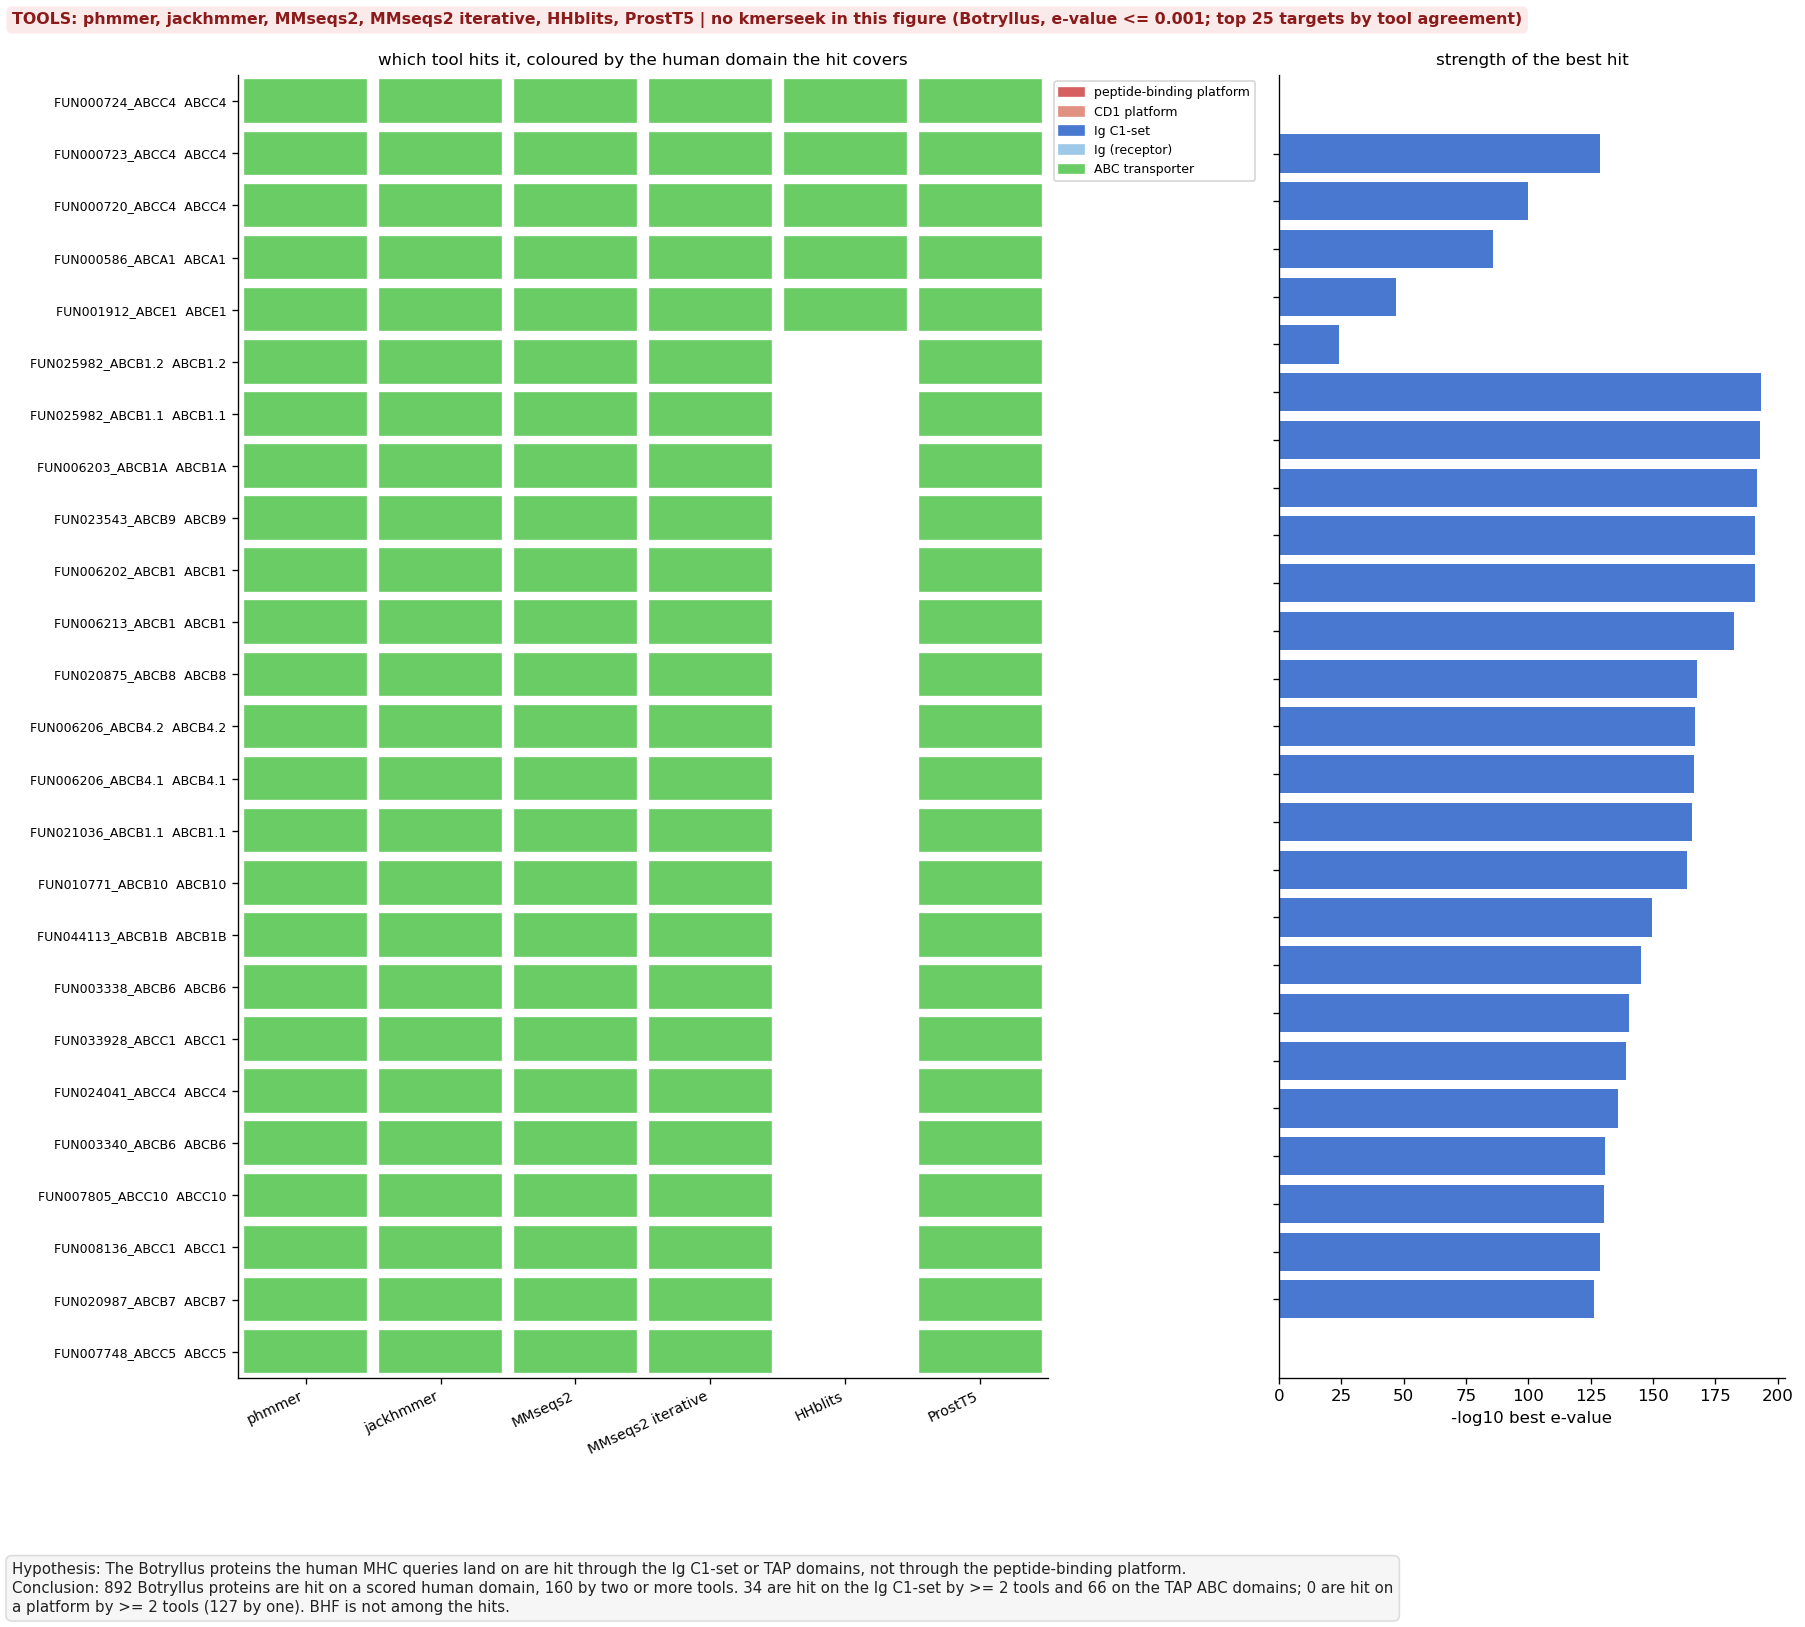

In [3]:
FASTA = Path("/Users/olga/data/quest-for-orthologs/QfO_release_2020_04_with_updated_UP000008143/Eukaryota/BOTSCH2026_30301.fasta")
seqs, name = {}, None
for line in open(FASTA):
    if line.startswith(">"):
        name = line[1:].split()[0]; seqs[name] = []
    else:
        seqs[name].append(line.strip())
seqs = {k: "".join(v) for k, v in seqs.items()}
print(f"Botryllus proteome: {len(seqs):_} proteins")


def hint(acc: str) -> str:
    tail = acc.split("_", 1)[1] if "_" in acc else acc
    return "" if tail.startswith("FUN") else tail


bot = HITS.filter(pl.col("species") == "botryllus")
per_target = (
    bot.group_by("target_acc")
    .agg(
        n_tools=pl.col("tool").n_unique(),
        tools=pl.col("tool").replace_strict(mu.TOOL_LABELS, default=pl.col("tool")).unique().sort().str.join(", "),
        n_queries=pl.col("query_acc").n_unique(),
        queries=pl.col("hgnc_symbol").unique().sort().str.join(", "),
        roles=pl.col("role").unique().sort().str.join(" + "),
        platform_tools=pl.col("tool").filter(pl.col("role").is_in(["peptide-binding platform", "CD1 platform"])).n_unique(),
        ig_tools=pl.col("tool").filter(pl.col("role") == "Ig C1-set").n_unique(),
        receptor_tools=pl.col("tool").filter(pl.col("role") == "Ig (receptor)").n_unique(),
        tap_tools=pl.col("tool").filter(pl.col("role") == "ABC transporter").n_unique(),
        best_evalue=pl.col("evalue").min(),
    )
    .with_columns(
        symbol_hint=pl.col("target_acc").map_elements(hint, return_dtype=pl.String),
        length=pl.col("target_acc").map_elements(lambda a: len(seqs.get(a, "")), return_dtype=pl.Int64),
    )
    .sort(["n_tools", "best_evalue"], descending=[True, False])
)
print(f"Botryllus proteins hit on a scored human domain by >= 1 tool: {per_target.height}")
print(f"  by >= 2 tools: {per_target.filter(pl.col('n_tools') >= 2).height}")
print(f"  hit on a platform domain by >= 1 tool: {per_target.filter(pl.col('platform_tools') >= 1).height}, "
      f"by >= 2 tools: {per_target.filter(pl.col('platform_tools') >= 2).height}")
print(f"  hit on an Ig C1-set domain by >= 2 tools: {per_target.filter(pl.col('ig_tools') >= 2).height}")
print(f"  hit on a TAP ABC domain by >= 2 tools: {per_target.filter(pl.col('tap_tools') >= 2).height}")
print(f"\nBHF ({BHF}) among the hits: {BHF in set(bot['target_acc'])}")
print("\nTop 30 Botryllus targets by tool agreement:")
with pl.Config(tbl_rows=30, tbl_width_chars=230, fmt_str_lengths=60):
    print(per_target.head(30).select("target_acc", "symbol_hint", "length", "n_tools", "platform_tools", "ig_tools",
                                     "receptor_tools", "tap_tools", "best_evalue", "queries"))
print("\nEvery Botryllus target hit on a platform domain, with the tool and query:")
with pl.Config(tbl_rows=40, tbl_width_chars=200, fmt_str_lengths=60):
    print(bot.filter(pl.col("role").is_in(["peptide-binding platform", "CD1 platform"]))
          .select("target_acc", "hgnc_symbol", "role", "tool", "qstart", "qend", "evalue").sort("evalue"))

TOP = per_target.head(25)
fig, axes = plt.subplots(1, 2, figsize=(15, 0.36 * TOP.height + 3.0), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
mat = np.zeros((TOP.height, len(SEQ_TOOLS)))
role_of = {}
for i, t in enumerate(TOP["target_acc"]):
    sub = bot.filter(pl.col("target_acc") == t)
    for j, tool in enumerate(SEQ_TOOLS):
        s = sub.filter(pl.col("tool") == tool)
        if s.height:
            mat[i, j] = 1
            role_of[(i, j)] = s.sort("evalue")["role"][0]
for (i, j), r in role_of.items():
    ax.add_patch(plt.Rectangle((j - 0.45, i - 0.4), 0.9, 0.8, color=mu.DOMAIN_ROLE_COLORS.get(r, "#999999")))
ax.set_xlim(-0.5, len(SEQ_TOOLS) - 0.5); ax.set_ylim(TOP.height - 0.5, -0.5)
ax.set_xticks(range(len(SEQ_TOOLS))); ax.set_xticklabels([mu.TOOL_LABELS[t] for t in SEQ_TOOLS], fontsize=8.5, rotation=25, ha="right")
ax.set_yticks(range(TOP.height))
ax.set_yticklabels([f"{a}  {h}" if h else a for a, h in zip(TOP["target_acc"], TOP["symbol_hint"])], fontsize=7.5)
ax.set_title("which tool hits it, coloured by the human domain the hit covers", fontsize=10)
handles = [mpatches.Patch(color=mu.DOMAIN_ROLE_COLORS[r], label=r) for r in ROLE_ORDER if r in set(bot["role"])]
ax.legend(handles=handles, fontsize=7.5, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax = axes[1]
y = np.arange(TOP.height)
ax.barh(y, -np.log10(TOP["best_evalue"].to_numpy().clip(1e-300)), color="#4878CF")
ax.set_yticks(y); ax.set_yticklabels([]); ax.invert_yaxis()
ax.set_xlabel("-log10 best e-value")
ax.set_title("strength of the best hit", fontsize=10)
for a_ in axes:
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
n_plat2 = per_target.filter(pl.col("platform_tools") >= 2).height
mu.finish_figure(
    fig,
    FIG_DIR / "228_botryllus_targets.png",
    tools=mu.tools_text(SEQ_TOOLS, note=f"Botryllus, e-value <= {EVALUE:g}; top {TOP.height} targets by tool agreement"),
    hypothesis="The Botryllus proteins the human MHC queries land on are hit through the Ig C1-set or TAP domains, not through the peptide-binding platform.",
    conclusion=(
        f"{per_target.height} Botryllus proteins are hit on a scored human domain, {per_target.filter(pl.col('n_tools') >= 2).height} by "
        f"two or more tools. {per_target.filter(pl.col('ig_tools') >= 2).height} are hit on the Ig C1-set by >= 2 tools and "
        f"{per_target.filter(pl.col('tap_tools') >= 2).height} on the TAP ABC domains; {n_plat2} are hit on a platform by >= 2 tools "
        f"({per_target.filter(pl.col('platform_tools') >= 1).height} by one). BHF is {'among' if BHF in set(bot['target_acc']) else 'not among'} the hits."
    ),
    footer_y=-0.06,
)

## 3. What those Botryllus proteins are, by Pfam

The run has no Pfam annotation for Botryllus, so the candidates are annotated here: the top
targets by tool agreement, plus every target hit on a platform domain, are pulled from the
staged Botryllus FASTA and scanned against Pfam-A with hmmscan (HMMER 3.4, gathering
thresholds), run in the pinned BioContainers image. The result is cached next to the extract.
The question is whether any of them carries a C1-set (PF07654) or an MHC platform family
(PF00129, PF00993, PF00969, PF16497), as opposed to the generic Ig families every animal has.

docker run --rm -v /Users/olga/data/pfam:/pfam:ro -v /Users/olga/data/qfo-pfam-region-midi-plus/botryllus_hmmscan:/work quay.io/biocontainers/hmmer:3.4--h7d74f8d_5 hmmscan --cpu 4 --cut_ga --noali --domtblout /work/candidates.domtbl /pfam/Pfam-A.hmm /work/candidates.fasta


candidates scanned: 194; with >= 1 Pfam domain at gathering threshold: 107

candidates carrying an MHC platform or C1-set family: 0
shape: (107, 8)
┌─────────────────────┬─────────────┬─────────┬────────────────┬──────────┬───────────┬───────────┬───────────────────────────────────────────────────────────────────┐
│ query_name          ┆ symbol_hint ┆ n_tools ┆ platform_tools ┆ ig_tools ┆ tap_tools ┆ has_c1set ┆ names                                                             │
│ ---                 ┆ ---         ┆ ---     ┆ ---            ┆ ---      ┆ ---       ┆ ---       ┆ ---                                                               │
│ str                 ┆ str         ┆ u32     ┆ u32            ┆ u32      ┆ u32       ┆ bool      ┆ str                                                               │
╞═════════════════════╪═════════════╪═════════╪════════════════╪══════════╪═══════════╪═══════════╪═══════════════════════════════════════════════════════════════════╡
│ FUN000724_

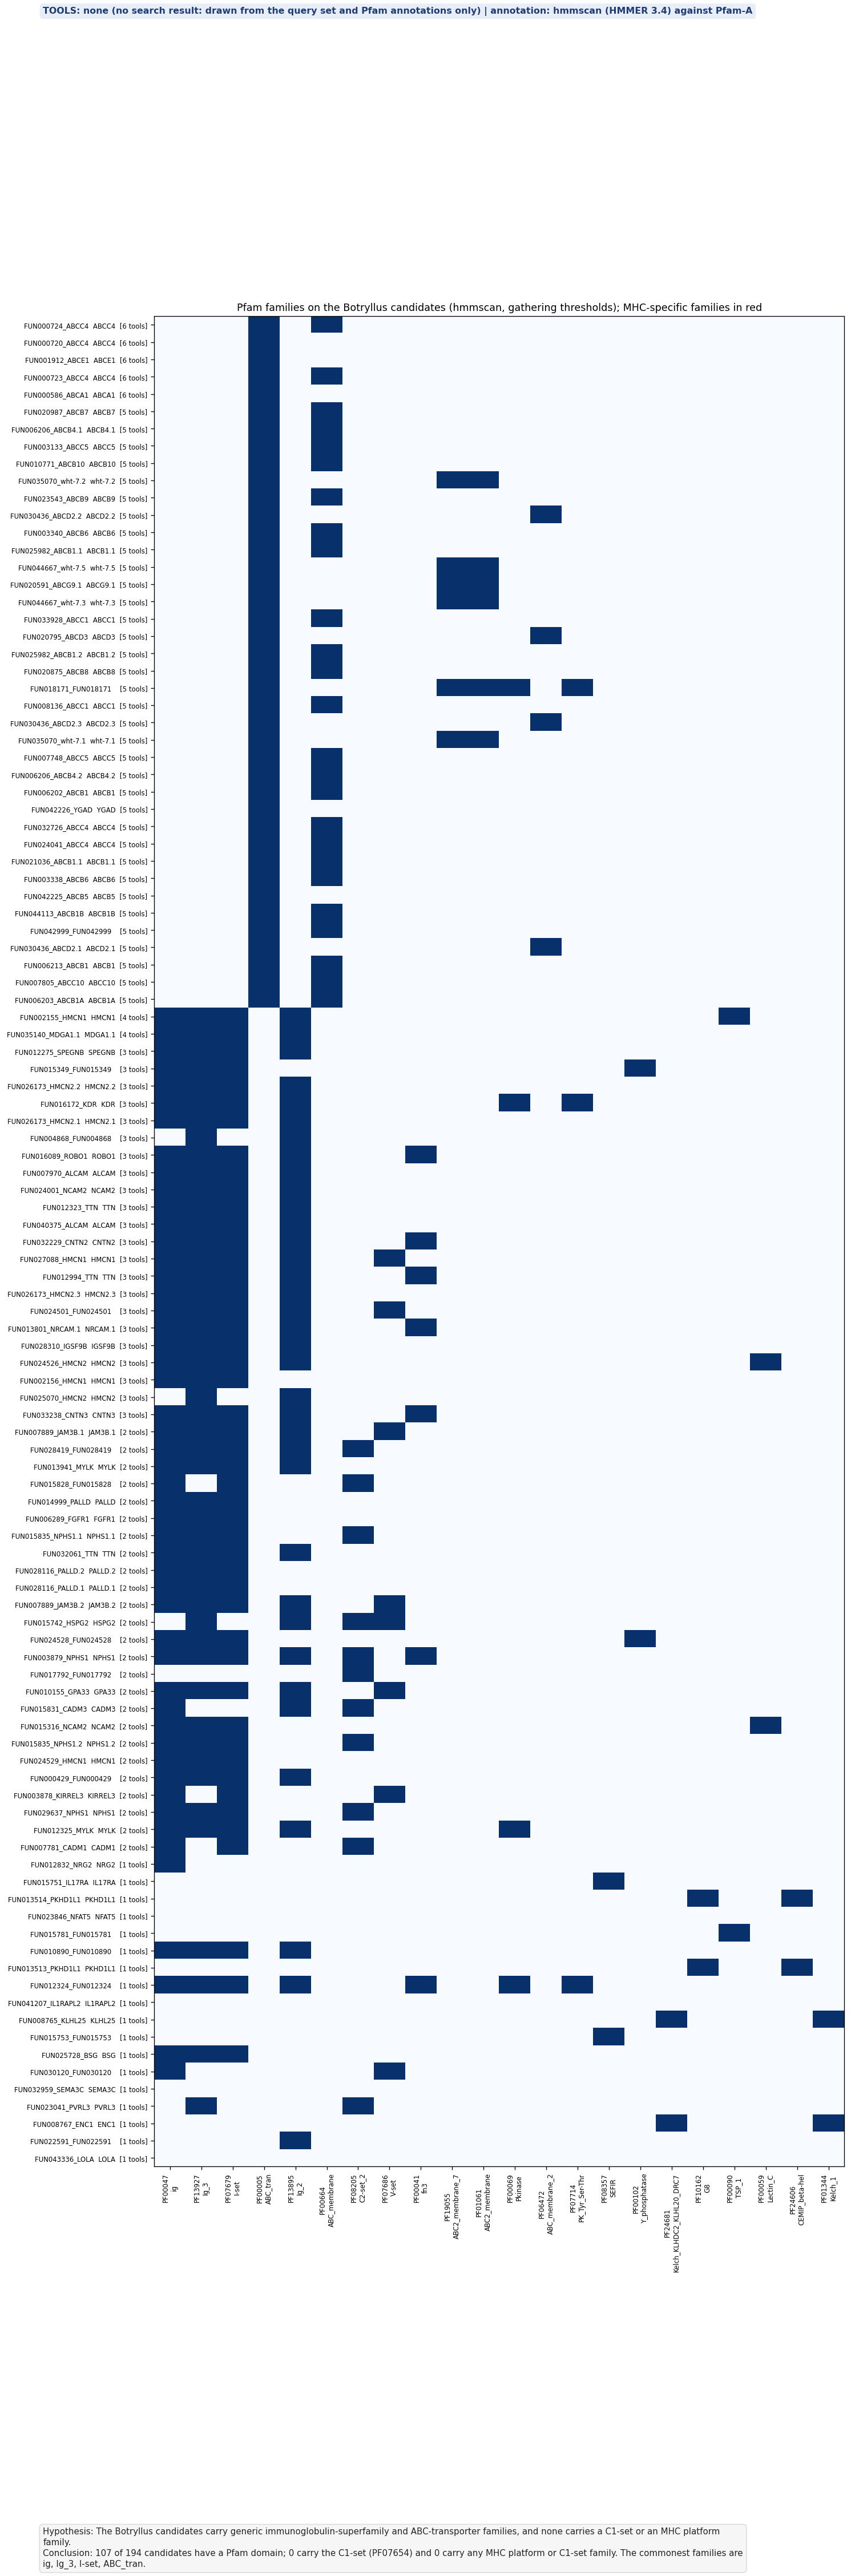

In [4]:
CAND = sorted(
    set(per_target.head(40)["target_acc"])
    | set(per_target.sort(["ig_tools", "best_evalue"], descending=[True, False]).head(40)["target_acc"])
    | set(per_target.filter(pl.col("platform_tools") >= 1)["target_acc"])
    | {BHF}
)
CACHE = mu.MIDI_DIR / "botryllus_candidates_pfam.parquet"
WORK = mu.MIDI_DIR / "botryllus_hmmscan"
WORK.mkdir(exist_ok=True)
IMG = "quay.io/biocontainers/hmmer:3.4--h7d74f8d_5"
PFAM_DIR = Path("/Users/olga/data/pfam")

DOMTBL_COLS = ["target_name", "target_acc", "tlen", "query_name", "query_acc", "qlen", "full_evalue", "full_score",
               "full_bias", "dom_n", "dom_of", "c_evalue", "i_evalue", "dom_score", "dom_bias", "hmm_from", "hmm_to",
               "ali_from", "ali_to", "env_from", "env_to", "acc"]


def parse_domtbl(path: Path) -> pl.DataFrame:
    rows = []
    for line in open(path):
        if line.startswith("#"):
            continue
        f = line.split(maxsplit=22)
        rows.append(dict(zip(DOMTBL_COLS, f[:22])) | {"description": f[22].strip() if len(f) > 22 else ""})
    df = pl.DataFrame(rows)
    return df.with_columns(
        [pl.col(c).cast(pl.Int64) for c in ["tlen", "qlen", "dom_n", "dom_of", "hmm_from", "hmm_to", "ali_from", "ali_to", "env_from", "env_to"]]
        + [pl.col(c).cast(pl.Float64) for c in ["full_evalue", "full_score", "c_evalue", "i_evalue", "dom_score"]]
    ).with_columns(pfam_id=pl.col("target_acc").str.split(".").list.get(0))


cached = pl.read_parquet(CACHE) if CACHE.exists() else None
if cached is None or set(CAND) - set(cached["query_name"].unique()):
    fa = WORK / "candidates.fasta"
    with open(fa, "w") as fh:
        for a in CAND:
            fh.write(f">{a}\n{seqs[a]}\n")
    cmd = ["docker", "run", "--rm", "-v", f"{PFAM_DIR}:/pfam:ro", "-v", f"{WORK}:/work", IMG,
           "hmmscan", "--cpu", "4", "--cut_ga", "--noali", "--domtblout", "/work/candidates.domtbl",
           "/pfam/Pfam-A.hmm", "/work/candidates.fasta"]
    print(" ".join(cmd))
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(r.stderr[-2000:])
    cached = parse_domtbl(WORK / "candidates.domtbl")
    scanned = pl.DataFrame({"query_name": CAND})  # keep candidates with no domain at all
    cached = scanned.join(cached, on="query_name", how="left")
    cached.write_parquet(CACHE)
ann = cached.filter(pl.col("pfam_id").is_not_null())
print(f"candidates scanned: {len(CAND)}; with >= 1 Pfam domain at gathering threshold: {ann['query_name'].n_unique()}")

MHC_FAMS = ["PF00129", "PF00993", "PF00969", "PF16497", "PF07654"]
IG_FAMS = ["PF00047", "PF13895", "PF13927", "PF07679", "PF07686", "PF08205", "PF13895", "PF00041", "PF07654"]
fam_tbl = (
    ann.group_by("query_name")
    .agg(families=pl.col("pfam_id").unique().sort().str.join(", "),
         names=pl.col("target_name").unique().sort().str.join(", "),
         has_mhc_family=pl.col("pfam_id").is_in(MHC_FAMS).any(),
         has_c1set=(pl.col("pfam_id") == "PF07654").any(),
         n_ig_like=pl.col("target_name").str.to_lowercase().str.contains("^ig|^i-set|^v-set|^c1-set|^c2-set").sum())
    .join(per_target.select("target_acc", "symbol_hint", "length", "n_tools", "platform_tools", "ig_tools", "tap_tools", "queries"),
          left_on="query_name", right_on="target_acc", how="left")
    .sort(["has_mhc_family", "n_tools"], descending=[True, True])
)
print(f"\ncandidates carrying an MHC platform or C1-set family: {int(fam_tbl['has_mhc_family'].sum())}")
with pl.Config(tbl_rows=60, tbl_width_chars=230, fmt_str_lengths=70):
    print(fam_tbl.select("query_name", "symbol_hint", "n_tools", "platform_tools", "ig_tools", "tap_tools", "has_c1set", "names"))

# Family x candidate presence matrix, families ordered by how many candidates carry them.
top_f = ann.group_by("target_name", "pfam_id").agg(n=pl.col("query_name").n_unique()).sort("n", descending=True).head(22)
fams = top_f["pfam_id"].to_list(); fnames = dict(zip(top_f["pfam_id"], top_f["target_name"]))
cands = fam_tbl["query_name"].to_list()
M = np.zeros((len(cands), len(fams)))
for i, c in enumerate(cands):
    got = set(ann.filter(pl.col("query_name") == c)["pfam_id"])
    for j, f in enumerate(fams):
        M[i, j] = f in got
fig, ax = plt.subplots(figsize=(13, 0.3 * len(cands) + 3))
ax.imshow(M, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(fams))); ax.set_xticklabels([f"{f}\n{fnames[f]}" for f in fams], fontsize=7, rotation=90)
ax.set_yticks(range(len(cands)))
ax.set_yticklabels([f"{c}  {h or ''}  [{n} tools]" for c, h, n in zip(cands, fam_tbl["symbol_hint"].fill_null(""), fam_tbl["n_tools"].fill_null(0))], fontsize=7)
for j, f in enumerate(fams):
    if f in MHC_FAMS:
        ax.get_xticklabels()[j].set_color("#D62728")
ax.set_title("Pfam families on the Botryllus candidates (hmmscan, gathering thresholds); MHC-specific families in red", fontsize=10.5)
n_c1 = int(fam_tbl["has_c1set"].sum()); n_mhc = int(fam_tbl["has_mhc_family"].sum())
mu.finish_figure(
    fig,
    FIG_DIR / "228_candidate_pfam.png",
    tools=mu.NO_TOOL + " | annotation: hmmscan (HMMER 3.4) against Pfam-A",
    hypothesis="The Botryllus candidates carry generic immunoglobulin-superfamily and ABC-transporter families, and none carries a C1-set or an MHC platform family.",
    conclusion=(
        f"{len(cands)} of {len(CAND)} candidates have a Pfam domain; {n_c1} carry the C1-set (PF07654) and {n_mhc} carry any MHC "
        f"platform or C1-set family. The commonest families are {', '.join(fnames[f] for f in fams[:4])}."
    ),
    layout=False,
    footer_y=-0.04,
)

## 4. kmerseek on Botryllus, with the arms that exist

Only five kmerseek arms ran against Botryllus, all from the all-QfO run and none HP: protein20
k=10, hsdm17 k=10, uniprot18 k=10, wass14 k=12 and mmseqs12 k=6, without the low-complexity
mask. This section asks the same question of them: which human domains do their Botryllus hits
cover, and do they land on the same Botryllus proteins as the sequence tools. mmseqs12 at k=6
emits millions of windows and is a near-random background, so it is shown but read last.

kmerseek arms with Botryllus hits (no LC mask):
shape: (4, 2)
┌─────────────────────────┬────────┐
│ arm                     ┆ len    │
│ ---                     ┆ ---    │
│ str                     ┆ u32    │
╞═════════════════════════╪════════╡
│ kmerseek mmseqs12 k=6   ┆ 388655 │
│ kmerseek hsdm17 k=10    ┆ 434    │
│ kmerseek protein20 k=10 ┆ 3      │
│ kmerseek uniprot18 k=10 ┆ 3      │
└─────────────────────────┴────────┘
shape: (16, 5)
┌───────────┬─────────────────────────┬──────────────────────────┬───────────┬─────────────────┐
│ species   ┆ arm                     ┆ peptide-binding platform ┆ Ig C1-set ┆ ABC transporter │
│ ---       ┆ ---                     ┆ ---                      ┆ ---       ┆ ---             │
│ str       ┆ str                     ┆ u32                      ┆ u32       ┆ u32             │
╞═══════════╪═════════════════════════╪══════════════════════════╪═══════════╪═════════════════╡
│ botryllus ┆ kmerseek hsdm17 k=10    ┆ 1                        ┆ 0

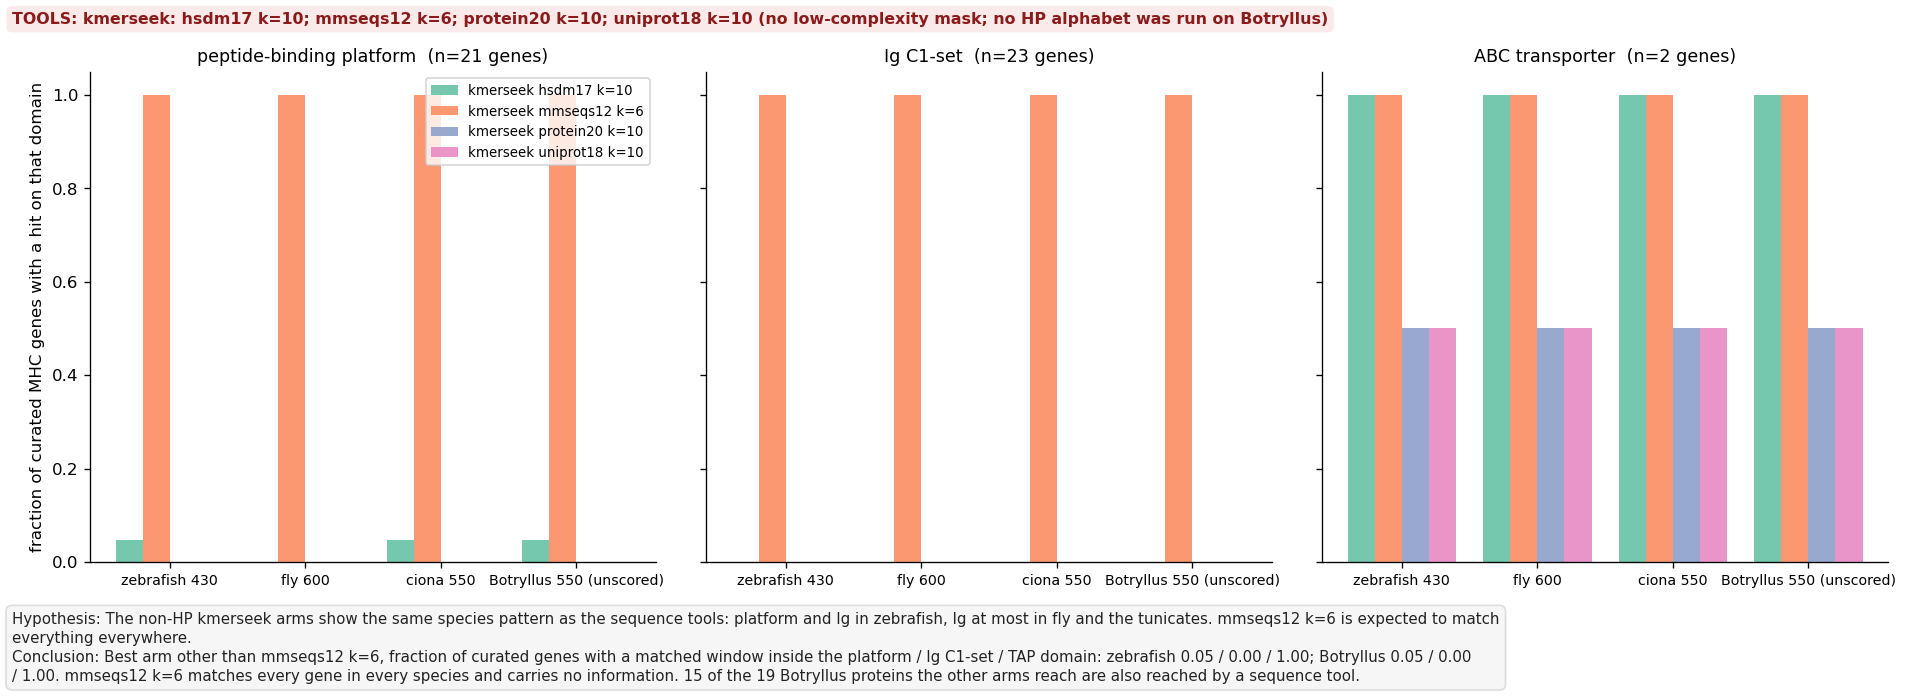

In [5]:
km = (
    pl.scan_parquet(mu.KMERSEEK_REGIONS)
    .filter(pl.col("species").is_in(SPECIES) & pl.col("query_acc").is_in(QACC) & (pl.col("lc") == False))
    .select("species", "alphabet", "ksize", "query_acc", "target_name", "region_start", "region_end",
            "region_poisson_score", "containment")
    .collect()
    .with_columns(target_acc=mu.uniprot_acc(pl.col("target_name")),
                  qstart=pl.col("region_start") + 1, qend=pl.col("region_end"),
                  arm=pl.lit("kmerseek ") + pl.col("alphabet") + pl.lit(" k=") + pl.col("ksize").cast(pl.String))
)
KHITS = label_hits(km, by="hit").join(QUERY, on="query_acc")
print("kmerseek arms with Botryllus hits (no LC mask):")
print(km.filter(pl.col("species") == "botryllus").group_by("arm").len().sort("len", descending=True))

kcnt = (
    KHITS.filter(pl.col("query_acc").is_in(CORE_ACC) & pl.col("role").is_in(ROLE3))
    .group_by("species", "arm", "role")
    .agg(n_genes=pl.col("query_acc").n_unique())
)
ARMS_K = sorted(km["arm"].unique().to_list())
kgrid = (
    pl.DataFrame({"species": SPECIES}).join(pl.DataFrame({"arm": ARMS_K}), how="cross")
    .join(pl.DataFrame({"role": ROLE3}), how="cross")
    .join(kcnt, on=["species", "arm", "role"], how="left")
    .with_columns(pl.col("n_genes").fill_null(0))
    .with_columns(frac=pl.col("n_genes") / pl.col("role").replace_strict(n_role))
)
with pl.Config(tbl_rows=80, tbl_width_chars=160):
    print(kgrid.pivot(on="role", index=["species", "arm"], values="n_genes").sort("species", "arm"))

# mmseqs12 at k=6 matches almost every query to almost every target and is left out of the
# agreement count; it is drawn in the figure for completeness.
kb = KHITS.filter((pl.col("species") == "botryllus") & (pl.col("alphabet") != "mmseqs12"))
agree = (
    kb.group_by("target_acc").agg(k_arms=pl.col("arm").n_unique(), k_roles=pl.col("role").unique().sort().str.join(" + "))
    .join(per_target.select("target_acc", "n_tools", "symbol_hint"), on="target_acc", how="left")
    .with_columns(pl.col("n_tools").fill_null(0))
    .sort(["n_tools", "k_arms"], descending=[True, True])
)
print(f"\nBotryllus proteins hit by a kmerseek arm other than mmseqs12 k=6 on a scored human domain: {agree.height}; also hit by >= 1 sequence tool: "
      f"{agree.filter(pl.col('n_tools') >= 1).height}")
with pl.Config(tbl_rows=20, tbl_width_chars=160, fmt_str_lengths=60):
    print(agree.head(20))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
w = 0.8 / len(ARMS_K)
for ax, role in zip(axes, ROLE3):
    for k, arm in enumerate(ARMS_K):
        v = [kgrid.filter((pl.col("species") == s) & (pl.col("arm") == arm) & (pl.col("role") == role))["frac"][0] for s in SPECIES]
        ax.bar(x + (k - (len(ARMS_K) - 1) / 2) * w, v, w, label=arm, color=plt.get_cmap("Set2")(k), alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([mu.SPECIES_LABELS[s].replace("\n", " ") for s in SPECIES], fontsize=8.5)
    ax.set_title(f"{role}  (n={n_role[role]} genes)", fontsize=10.5)
    ax.set_ylim(0, 1.05)
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
axes[0].set_ylabel("fraction of curated MHC genes with a hit on that domain")
axes[0].legend(fontsize=8, loc="upper right")
def _k(sp, role):
    return kgrid.filter((pl.col("species") == sp) & (pl.col("role") == role) & ~pl.col("arm").str.contains("mmseqs12"))["frac"].max()
mu.finish_figure(
    fig,
    FIG_DIR / "228_kmerseek_pattern.png",
    tools=mu.tools_text(kmerseek="kmerseek: " + "; ".join(a.replace("kmerseek ", "") for a in ARMS_K) + " (no low-complexity mask; no HP alphabet was run on Botryllus)"),
    hypothesis="The non-HP kmerseek arms show the same species pattern as the sequence tools: platform and Ig in zebrafish, Ig at most in fly and the tunicates. mmseqs12 k=6 is expected to match everything everywhere.",
    conclusion=(
        f"Best arm other than mmseqs12 k=6, fraction of curated genes with a matched window inside the platform / Ig C1-set / TAP domain: zebrafish {_k('zebrafish', ROLE3[0]):.2f} / "
        f"{_k('zebrafish', ROLE3[1]):.2f} / {_k('zebrafish', ROLE3[2]):.2f}; Botryllus {_k('botryllus', ROLE3[0]):.2f} / "
        f"{_k('botryllus', ROLE3[1]):.2f} / {_k('botryllus', ROLE3[2]):.2f}. mmseqs12 k=6 matches every gene in every species and carries no information. "
        f"{agree.filter(pl.col('n_tools') >= 1).height} of the {agree.height} Botryllus proteins the other arms reach are also reached by a sequence tool."
    ),
)

## 5. The prediction

Putative MHC-related genes in Botryllus, in the only sense the data support: Botryllus
proteins that the human MHC molecules reach through their Ig C1-set half by two or more
independent sequence tools, and the TAP orthologs reached through the ABC-transporter domains.
The table is the deliverable; the class column says which human queries reach each protein.

predicted MHC-related Botryllus proteins: 100
shape: (2, 2)
┌─────────────────────────────────┬─────┐
│ call                            ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ TAP ortholog (ABC transporter)  ┆ 66  │
│ IgSF relative of the MHC C1-se… ┆ 34  │
└─────────────────────────────────┴─────┘
shape: (100, 8)
┌─────────────────────┬─────────────┬────────┬─────────────────────────────────┬─────────┬─────────────┬───────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────┐
│ target_acc          ┆ symbol_hint ┆ length ┆ call                            ┆ n_tools ┆ best_evalue ┆ queries                                                           ┆ names                                                             │
│ ---                 ┆ ---         ┆ ---    ┆ ---                             ┆ ---     ┆ ---         ┆ -

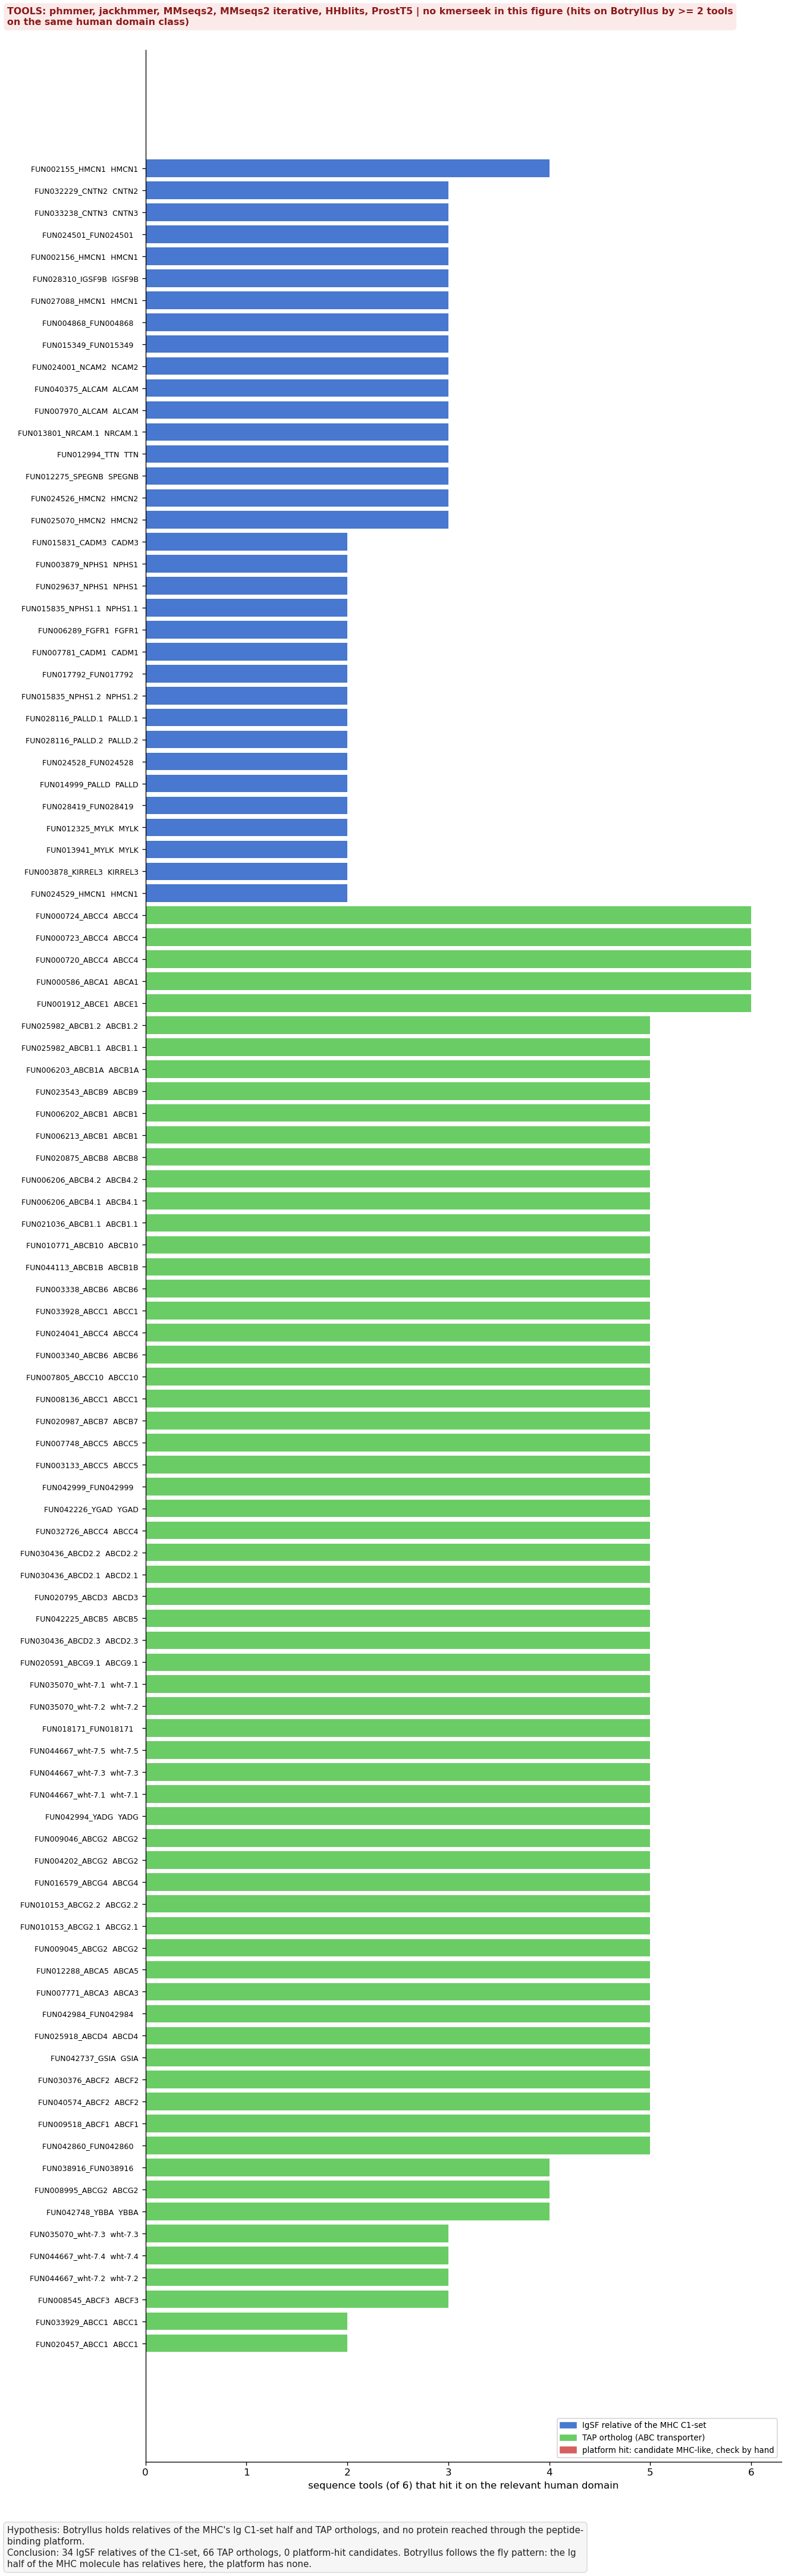

In [6]:
pred = (
    per_target.filter((pl.col("ig_tools") >= 2) | (pl.col("tap_tools") >= 2) | (pl.col("platform_tools") >= 2))
    .join(fam_tbl.select("query_name", "names", "has_c1set", "has_mhc_family"), left_on="target_acc", right_on="query_name", how="left")
    .with_columns(
        call=pl.when(pl.col("platform_tools") >= 2).then(pl.lit("platform hit: candidate MHC-like, check by hand"))
        .when(pl.col("tap_tools") >= 2).then(pl.lit("TAP ortholog (ABC transporter)"))
        .otherwise(pl.lit("IgSF relative of the MHC C1-set"))
    )
    .sort(["call", "n_tools", "best_evalue"], descending=[False, True, False])
)
print(f"predicted MHC-related Botryllus proteins: {pred.height}")
print(pred.group_by("call").len().sort("len", descending=True))
with pl.Config(tbl_rows=60, tbl_width_chars=240, fmt_str_lengths=70):
    print(pred.select("target_acc", "symbol_hint", "length", "call", "n_tools", "best_evalue", "queries", "names"))
pred.write_csv(mu.MIDI_DIR / "botryllus_putative_mhc_related.csv")
print(f"\nwritten: {mu.MIDI_DIR / 'botryllus_putative_mhc_related.csv'}")

fig, ax = plt.subplots(figsize=(11, 0.32 * pred.height + 2.5))
y = np.arange(pred.height)
colors = {"IgSF relative of the MHC C1-set": mu.DOMAIN_ROLE_COLORS["Ig C1-set"],
          "TAP ortholog (ABC transporter)": mu.DOMAIN_ROLE_COLORS["ABC transporter"],
          "platform hit: candidate MHC-like, check by hand": mu.DOMAIN_ROLE_COLORS["peptide-binding platform"]}
ax.barh(y, pred["n_tools"], color=[colors[c] for c in pred["call"]])
ax.set_yticks(y)
ax.set_yticklabels([f"{a}  {h or ''}" for a, h in zip(pred["target_acc"], pred["symbol_hint"].fill_null(""))], fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel("sequence tools (of 6) that hit it on the relevant human domain")
ax.legend(handles=[mpatches.Patch(color=v, label=k) for k, v in colors.items()], fontsize=8, loc="lower right")
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
nc = dict(pred.group_by("call").len().iter_rows())
mu.finish_figure(
    fig,
    FIG_DIR / "228_prediction.png",
    tools=mu.tools_text(SEQ_TOOLS, note="hits on Botryllus by >= 2 tools on the same human domain class"),
    hypothesis="Botryllus holds relatives of the MHC's Ig C1-set half and TAP orthologs, and no protein reached through the peptide-binding platform.",
    conclusion=(
        f"{nc.get('IgSF relative of the MHC C1-set', 0)} IgSF relatives of the C1-set, {nc.get('TAP ortholog (ABC transporter)', 0)} TAP "
        f"orthologs, {nc.get('platform hit: candidate MHC-like, check by hand', 0)} platform-hit candidates. Botryllus follows the fly "
        "pattern: the Ig half of the MHC molecule has relatives here, the platform has none."
    ),
)

## Summary

Read the printed tables for the numbers; the figures above carry the conclusions. Three things
frame them.

Botryllus follows the fly pattern, not the zebrafish one. The human MHC molecules reach
Botryllus proteins through their Ig C1-set half and TAP reaches ABC transporters, while the
peptide-binding platform, the part of the molecule that makes an MHC an MHC, has no partner
that more than one tool agrees on. The same six tools find platform partners in zebrafish on
the same queries with the same e-value cut, so the absence is not a tool failure.

The candidates are immunoglobulin-superfamily proteins. hmmscan against Pfam-A says what the
reached Botryllus proteins are made of, and the families are the generic Ig, I-set and V-set
folds shared by every animal; whether any carries a C1-set is stated in the §3 figure. An IgSF
protein reached through the MHC's C1-set is a relative of the fold, not of the molecule, which
is the same distinction notebooks 220 and 221 draw for fly.

Two limits. No structure tool ran on Botryllus, so ProstT5's predicted 3Di is the only
structure-aware view. And kmerseek's HP alphabets, the arms this project cares about, were
never searched against Botryllus; the five arms that exist are the all-QfO run's non-HP set.
To add the HP arms, run the midi-plus target on Sherlock from the pipeline directory, which
reuses every stored search and runs only the missing Botryllus arms:

```bash
cd $SCRATCH/2024-kmerseek-analysis/nextflow-runs/qfo-pfam-region-benchmark && make run-midi-plus
```

Once those searches exist, re-run `scripts/extract_mhc.py` with the HP combos added to
`--region-combos` for Botryllus and this notebook's §4 picks them up without other changes.